# 01 · EDA & Preprocessing
**Churn Detective — Telecom Retention Brief**

**Goal:** Load and audit the raw data, run churn-stratified EDA, engineer features, and output clean train/test parquet files for all downstream notebooks.

**Outputs:**
- `data/processed/train.parquet`
- `data/processed/test.parquet`  
- `data/processed/churners_only.parquet`
- `outputs/figures/eda_*.png` — churn-stratified univariate plots

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.features import (
    load_raw, drop_unusable, add_engineered_features,
    prepare_for_lgbm, RAW_SCHEMA, KMEANS_FEATURES
)

# ── Plot style ────────────────────────────────────────────────────────
NAVY   = '#111e35'
TEAL   = '#2dd4bf'
AMBER  = '#fbbf24'
ROSE   = '#fb7185'
SLATE  = '#94a3b8'

plt.rcParams.update({
    'figure.facecolor' : NAVY,
    'axes.facecolor'   : NAVY,
    'axes.edgecolor'   : '#1a2d4e',
    'axes.labelcolor'  : SLATE,
    'xtick.color'      : SLATE,
    'ytick.color'      : SLATE,
    'text.color'       : '#cbd5e1',
    'grid.color'       : '#1a2d4e',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'sans-serif',
    'figure.dpi'       : 130,
})

FIG_DIR = '../outputs/figures'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Audit

In [2]:
RAW_PATH = '../data/raw/case4_telecom_churn.csv'

df_raw = load_raw(RAW_PATH)
print(f'Shape: {df_raw.shape}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Shape: (7000, 21)
Columns: ['customer_id', 'tenure_months', 'contract_type', 'monthly_charges', 'total_charges', 'internet_service', 'online_security', 'tech_support', 'streaming_tv', 'payment_method', 'paperless_billing', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'support_calls_3mo', 'avg_data_gb_3mo', 'late_payments_6mo', 'plan_changes_6mo', 'churned']


,customer_id,tenure_months,contract_type,monthly_charges,total_charges,internet_service,online_security,tech_support,streaming_tv,payment_method,...,senior_citizen,partner,dependents,phone_service,multiple_lines,support_calls_3mo,avg_data_gb_3mo,late_payments_6mo,plan_changes_6mo,churned
0,CUST50000,8,Month-to-month,44.30,309.51,DSL,No,No,No,Electronic check,...,0,No,Yes,Yes,No,1,30.45,0,0,1
1,CUST50001,24,Month-to-month,100.38,2196.66,Fiber optic,No,Yes,No,Electronic check,...,0,Yes,No,Yes,Yes,3,57.32,0,1,1
2,CUST50002,10,Month-to-month,106.34,974.70,DSL,Yes,No,Yes,Bank transfer (auto),...,0,No,Yes,Yes,No,0,6.47,0,0,1


In [3]:
# ── Null audit ────────────────────────────────────────────────────────
null_report = pd.DataFrame({
    'null_count' : df_raw.isnull().sum(),
    'null_pct'   : (df_raw.isnull().mean() * 100).round(2),
    'dtype'      : df_raw.dtypes,
}).sort_values('null_count', ascending=False)

print('=== Null Report ===')
print(null_report[null_report['null_count'] > 0].to_string())
print(f'\nNo nulls in {(null_report["null_count"] == 0).sum()} columns.')

=== Null Report ===
Empty DataFrame
Columns: [null_count, null_pct, dtype]
Index: []

No nulls in 21 columns.


In [4]:
# ── Duplicate check ───────────────────────────────────────────────────
dup_ids = df_raw['customer_id'].duplicated().sum()
dup_rows = df_raw.duplicated().sum()
print(f'Duplicate customer_ids : {dup_ids}')
print(f'Fully duplicate rows   : {dup_rows}')

# ── Target distribution ───────────────────────────────────────────────
churn_counts = df_raw['churned'].value_counts()
churn_rate   = df_raw['churned'].mean()
print(f'\nChurn rate: {churn_rate:.3f} ({churn_rate*100:.1f}%)')
print(churn_counts)

Duplicate customer_ids : 0
Fully duplicate rows   : 0

Churn rate: 0.362 (36.2%)
churned
0    4469
1    2531
Name: count, dtype: int64


In [5]:
# ── Numeric summary ───────────────────────────────────────────────────
df_raw[RAW_SCHEMA['numeric']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
tenure_months,7000.0,22.64,20.38,1.00,7.00,16.00,33.00,72.00
monthly_charges,7000.0,69.84,28.88,20.01,45.16,69.80,94.79,120.00
total_charges,7000.0,1507.14,1606.22,18.01,350.26,947.13,2075.50,8825.94
support_calls_3mo,7000.0,2.09,2.14,0.00,1.00,2.00,3.00,14.00
avg_data_gb_3mo,7000.0,23.69,22.03,0.00,5.89,19.06,35.63,136.93
late_payments_6mo,7000.0,0.41,0.63,0.00,0.00,0.00,1.00,5.00
plan_changes_6mo,7000.0,0.50,0.70,0.00,0.00,0.00,1.00,5.00
senior_citizen,7000.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00


In [6]:
# ── Categorical value counts ──────────────────────────────────────────
for col in RAW_SCHEMA['categorical']:
    print(f'\n{col}:')
    print(df_raw[col].value_counts().to_string())


contract_type:
contract_type
Month-to-month    3857
One year          1786
Two year          1357

internet_service:
internet_service
Fiber optic    3158
DSL            2449
No             1393

online_security:
online_security
No                     3930
Yes                    1677
No internet service    1393

tech_support:
tech_support
No                     3817
Yes                    1790
No internet service    1393

streaming_tv:
streaming_tv
No                     3312
Yes                    2295
No internet service    1393

payment_method:
payment_method
Electronic check        2403
Credit card (auto)      1625
Bank transfer (auto)    1561
Mailed check            1411

paperless_billing:
paperless_billing
No     3515
Yes    3485

partner:
partner
No     3592
Yes    3408

dependents:
dependents
No     3580
Yes    3420

phone_service:
phone_service
Yes    6307
No      693

multiple_lines:
multiple_lines
No                  3202
Yes                 3105
No phone service     693


## 2. Churn-Stratified Univariate EDA

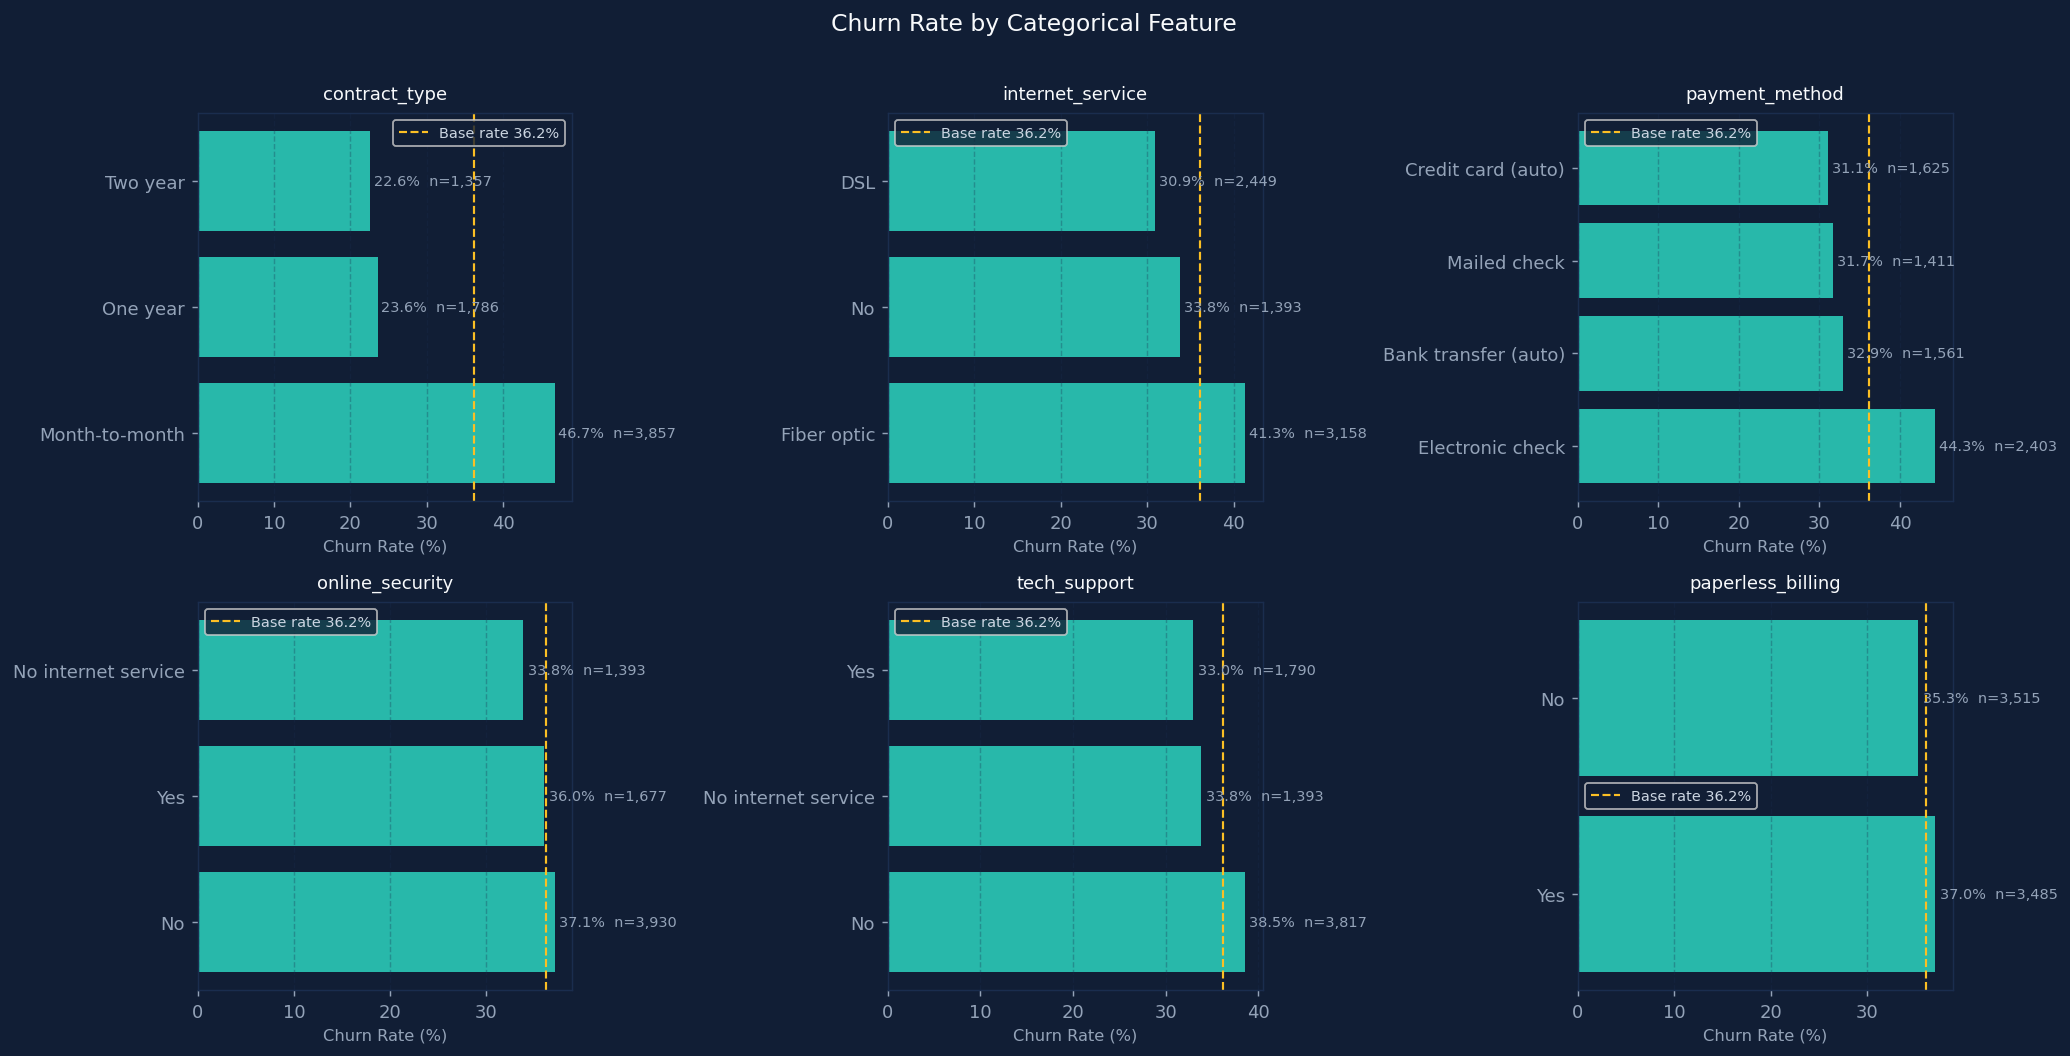

Saved eda_categorical_churn_rates.png


In [7]:
# ── Helper: churn rate by categorical group ───────────────────────────
def churn_rate_by(df, col, ax, title=None, color_churned=ROSE, color_retained=TEAL):
    """Bar chart of churn rate per category level, sorted descending."""
    grp = df.groupby(col)['churned'].agg(['mean', 'count']).reset_index()
    grp.columns = [col, 'churn_rate', 'n']
    grp = grp.sort_values('churn_rate', ascending=False)
    
    bars = ax.barh(grp[col], grp['churn_rate'] * 100, color=TEAL, alpha=0.85)
    ax.axvline(df['churned'].mean() * 100, color=AMBER, linestyle='--',
               linewidth=1.2, label=f'Base rate {df["churned"].mean()*100:.1f}%')
    
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{row["churn_rate"]*100:.1f}%  n={int(row["n"]):,}',
                va='center', ha='left', fontsize=8, color=SLATE)
    
    ax.set_xlabel('Churn Rate (%)', fontsize=9)
    ax.set_title(title or col, fontsize=10, pad=8, color='#f8fafc')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)
    ax.set_facecolor(NAVY)
    return ax


# ── Plot key categoricals ─────────────────────────────────────────────
key_cats = ['contract_type', 'internet_service', 'payment_method',
            'online_security', 'tech_support', 'paperless_billing']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor(NAVY)
fig.suptitle('Churn Rate by Categorical Feature', fontsize=13,
             color='#f8fafc', y=1.01)

for ax, col in zip(axes.flat, key_cats):
    churn_rate_by(df_raw, col, ax)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_categorical_churn_rates.png',
            bbox_inches='tight', dpi=130, facecolor=NAVY)
plt.show()
print('Saved eda_categorical_churn_rates.png')

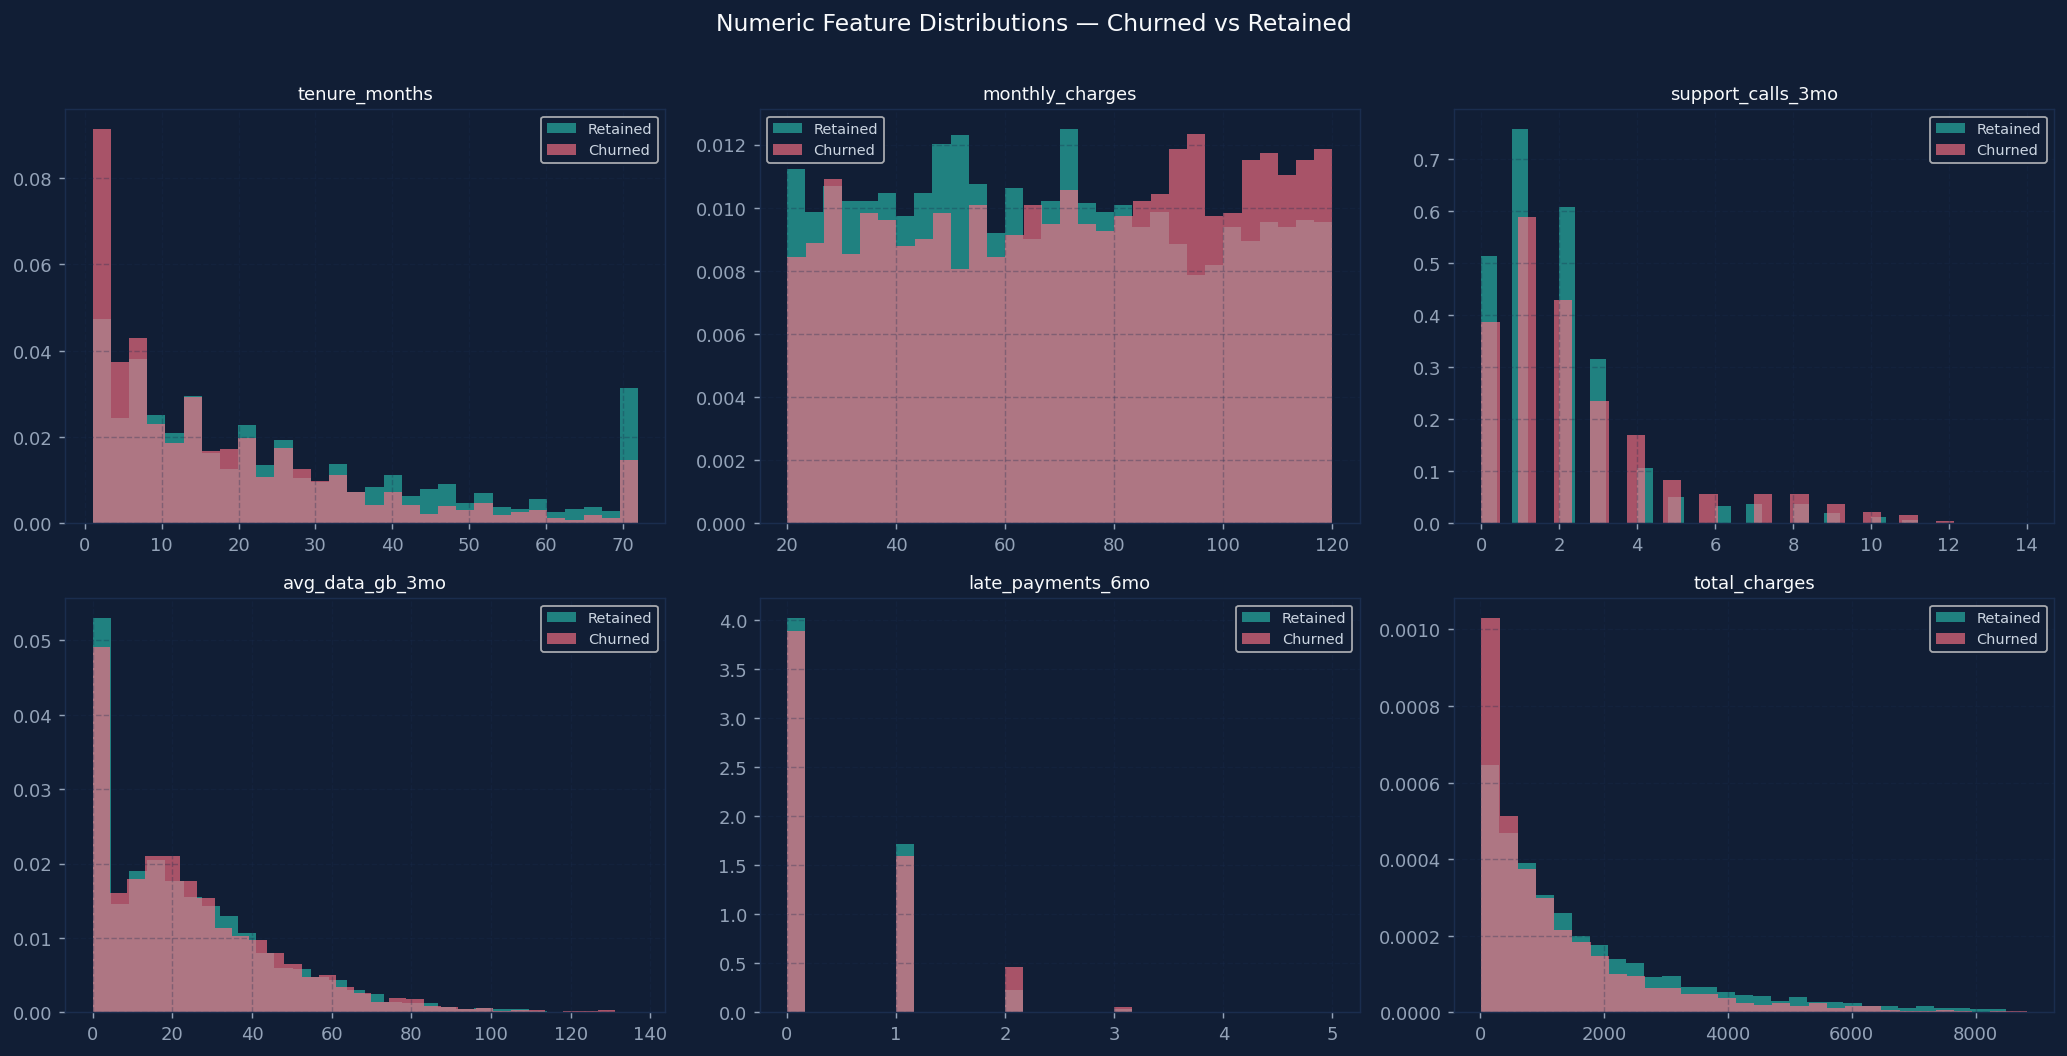

Saved eda_numeric_distributions.png


In [8]:
# ── Numeric distributions stratified by churn ─────────────────────────
key_nums = ['tenure_months', 'monthly_charges', 'support_calls_3mo',
            'avg_data_gb_3mo', 'late_payments_6mo', 'total_charges']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor(NAVY)
fig.suptitle('Numeric Feature Distributions — Churned vs Retained',
             fontsize=13, color='#f8fafc', y=1.01)

for ax, col in zip(axes.flat, key_nums):
    for label, color, alpha in [(0, TEAL, 0.55), (1, ROSE, 0.65)]:
        subset = df_raw[df_raw['churned'] == label][col].dropna()
        ax.hist(subset, bins=30, color=color, alpha=alpha,
                label='Retained' if label == 0 else 'Churned',
                density=True, edgecolor='none')
    ax.set_title(col, fontsize=10, color='#f8fafc', pad=6)
    ax.set_facecolor(NAVY)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_numeric_distributions.png',
            bbox_inches='tight', dpi=130, facecolor=NAVY)
plt.show()
print('Saved eda_numeric_distributions.png')

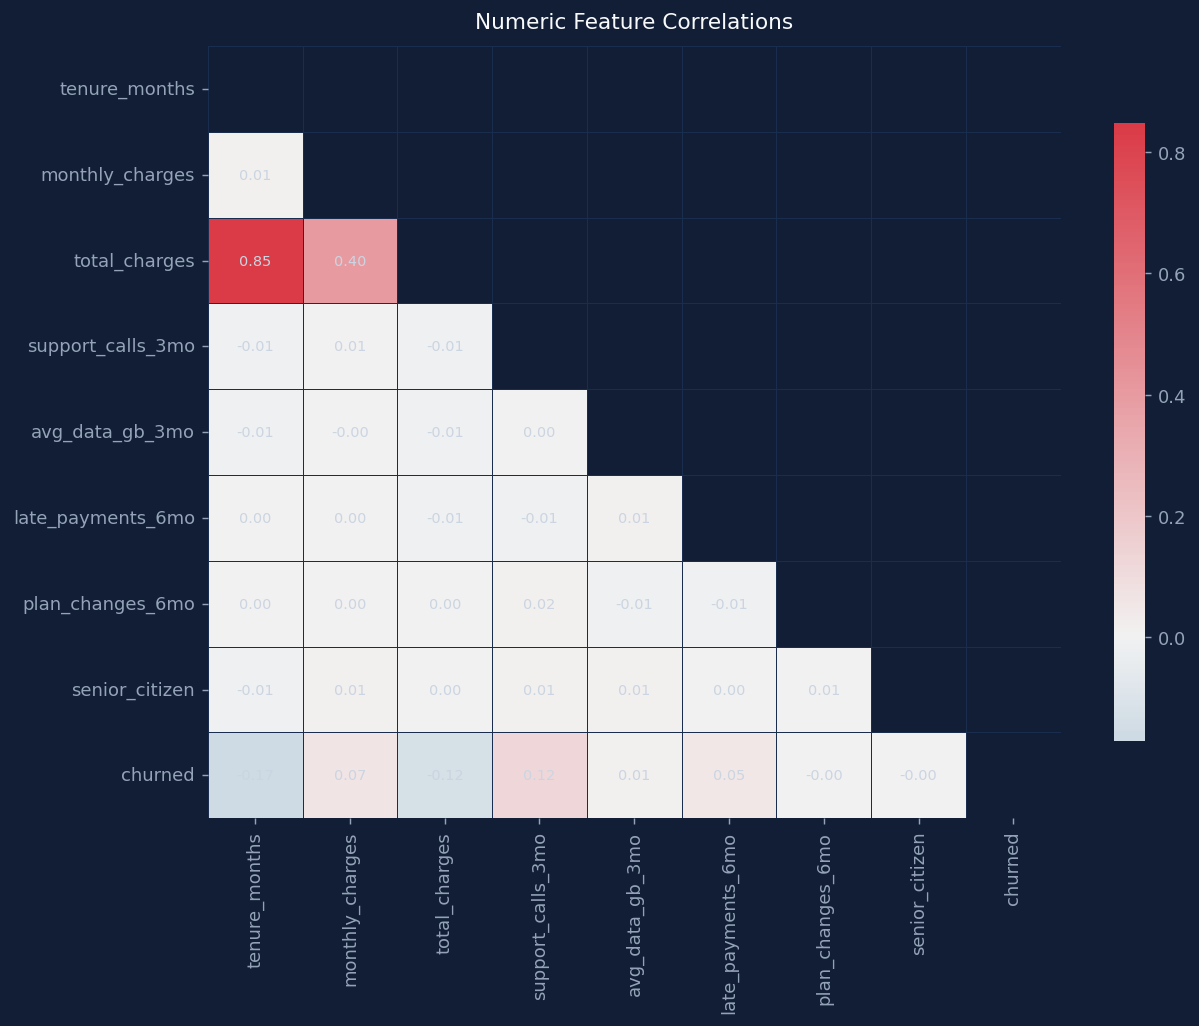


⚠  total_charges ~ monthly_charges × tenure_months  correlation: 0.9965
   This near-identity is expected. We keep total_charges but monitor for data leakage.


In [9]:
# ── Correlation heatmap (numeric only) ───────────────────────────────
num_cols = RAW_SCHEMA['numeric'] + ['churned']
corr = df_raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(NAVY)
ax.set_facecolor(NAVY)

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(240, 10, as_cmap=True)
sns.heatmap(
    corr, mask=mask, cmap=cmap, center=0,
    annot=True, fmt='.2f', annot_kws={'size': 8, 'color': '#cbd5e1'},
    linewidths=0.5, linecolor='#1a2d4e',
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Numeric Feature Correlations', fontsize=12,
             color='#f8fafc', pad=10)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/eda_correlation_heatmap.png',
            bbox_inches='tight', dpi=130, facecolor=NAVY)
plt.show()

# ── Flag the total_charges / (tenure × monthly) near-identity ─────────
corr_tc_mc = df_raw['total_charges'].corr(df_raw['monthly_charges'] * df_raw['tenure_months'])
print(f'\n⚠  total_charges ~ monthly_charges × tenure_months  correlation: {corr_tc_mc:.4f}')
print('   This near-identity is expected. We keep total_charges but monitor for data leakage.')

## 3. Feature Engineering

In [10]:
df_clean = load_raw(RAW_PATH)
df_clean = drop_unusable(df_clean)
df_clean = add_engineered_features(df_clean)

print(f'Clean shape: {df_clean.shape}')
print('\nEngineered feature sample:')
df_clean[['customer_id', 'charges_per_tenure_month',
           'service_frustration_index', 'is_new_customer',
           'is_long_tenure', 'has_no_support_services',
           'payment_is_manual']].head(6)

Clean shape: (7000, 28)

Engineered feature sample:


,customer_id,charges_per_tenure_month,service_frustration_index,is_new_customer,is_long_tenure,has_no_support_services,payment_is_manual
0,CUST50000,34.3900,1,0,0,1,1
1,CUST50001,87.8664,3,0,0,0,1
2,CUST50002,88.6091,0,0,0,0,0
3,CUST50003,58.6842,1,0,1,1,0
4,CUST50004,92.3567,1,0,0,0,1
5,CUST50005,50.9667,1,0,0,1,0


In [11]:
# ── Validate engineered features have churn signal ────────────────────
eng_features = [
    'service_frustration_index', 'is_new_customer',
    'has_no_support_services', 'payment_is_manual',
]

print('Churn rate by engineered feature value:\n')
for feat in eng_features:
    grp = df_clean.groupby(feat)['churned'].mean().round(3)
    print(f'{feat}:')
    print(grp.to_string())
    print()

Churn rate by engineered feature value:

service_frustration_index:
service_frustration_index
0     0.326
1     0.329
2     0.324
3     0.328
4     0.421
5     0.521
6     0.505
7     0.525
8     0.484
9     0.526
10    0.597
11    0.571
12    0.765
13    0.600
14    1.000
15    1.000

is_new_customer:
is_new_customer
0    0.318
1    0.494

has_no_support_services:
has_no_support_services
0    0.350
1    0.369

payment_is_manual:
payment_is_manual
0    0.320
1    0.396



## 4. Train / Test Split & Save

In [12]:
RANDOM_STATE = 42
TEST_SIZE    = 0.20

y  = df_clean['churned']
X  = df_clean.drop(columns=['churned'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    stratify     = y,
    random_state = RANDOM_STATE,
)

train_df = X_train.copy()
train_df['churned'] = y_train.values

test_df = X_test.copy()
test_df['churned'] = y_test.values

print(f'Train: {train_df.shape}  |  churn rate: {train_df["churned"].mean():.3f}')
print(f'Test:  {test_df.shape}   |  churn rate: {test_df["churned"].mean():.3f}')
print(f'\nStratification check — base rate {y.mean():.3f} preserved ✓')

Train: (5600, 28)  |  churn rate: 0.362
Test:  (1400, 28)   |  churn rate: 0.361

Stratification check — base rate 0.362 preserved ✓


In [13]:
# ── Churners-only subset (for segmentation notebook) ──────────────────
churners_only = train_df[train_df['churned'] == 1].reset_index(drop=True)
print(f'Churners-only (train): {len(churners_only)} rows')

# ── Save to parquet ───────────────────────────────────────────────────
train_df.to_parquet('../data/processed/train.parquet', index=False)
test_df.to_parquet('../data/processed/test.parquet', index=False)
churners_only.to_parquet('../data/processed/churners_only.parquet', index=False)

print('\nSaved:')
print('  data/processed/train.parquet')
print('  data/processed/test.parquet')
print('  data/processed/churners_only.parquet')
print('\n✓ Notebook 01 complete. Proceed to 02_baseline_model.ipynb')

Churners-only (train): 2025 rows



Saved:
  data/processed/train.parquet
  data/processed/test.parquet
  data/processed/churners_only.parquet

✓ Notebook 01 complete. Proceed to 02_baseline_model.ipynb
